# 01 — Exploratory Data Analysis & Hypothesis Testing
**Project:** Regime-Aware Direction Classification for Gold & Silver  
**Data:** Gold (GC=F), Silver (SI=F), VIX, 10Y Treasury, USD Index | Feb 2010 – Mar 2026  
**Goal:** Understand the data — distributions, stationarity, macro relationships — before modelling.

## Setup & Data Load

In [31]:
from google.colab import files
files.upload()

Saving gold_silver.csv to gold_silver.csv


{'gold_silver.csv': b'ID_Column,Date,usd_idx,gold,silver,interest,vix,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean\n0,2010-03-03,79.9800033569336,1142.699951171875,17.30900001525879,3.625,18.829999923706055,0.005088558812882546,0.015428325982542965,0.01454598124843938,0.024607414386918318,0.0016277212453685555,0.001839820251424261\n1,2010-03-04,80.55999755859375,1132.5999755859375,17.1560001373291,3.6059999465942383,18.719999313354492,-0.008877987298245592,-0.008878623666452798,0.014523091700857109,0.024704694142606762,0.0006433939642808489,0.0011802801490433572\n2,2010-03-05,80.43000030517578,1134.800048828125,17.36199951171875,3.681999921798706,17.420000076293945,0.0019406138387151374,0.011935907186694364,0.01445890974812581,0.024007617757661553,0.0009921887214231727,0.002976452283681709\n3,2010-03-08,80.43000030517578,1123.5999755859375,17.25200080871582,3.7079999446868896,17.790000915527344,-0.009918672460992171,-0.0063557561838186154,0.010290228806466599,0.01918771148213192

In [34]:
df = pd.read_csv("gold_silver.csv")
print(df.columns.tolist())

['ID_Column', 'Date', 'usd_idx', 'gold', 'silver', 'interest', 'vix', 'au_returns', 'ag_returns', 'au_vol', 'ag_vol', 'au_mean', 'ag_mean']


In [36]:
import pandas as pd

df = pd.read_csv(
    "gold_silver.csv",
    parse_dates=["Date"]
)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('darkgrid')

df = pd.read_csv('gold_silver.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print(f"Shape      : {df.shape}")
print(f"Columns    : {df.columns.tolist()}")
df.head()

Shape      : (4092, 12)
Columns    : ['ID_Column', 'usd_idx', 'gold', 'silver', 'interest', 'vix', 'au_returns', 'ag_returns', 'au_vol', 'ag_vol', 'au_mean', 'ag_mean']


,ID_Column,usd_idx,gold,silver,interest,vix,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean
Date,,,,,,,,,,,,
2010-03-03,0,79.980003,1142.699951,17.309000,3.625,18.830000,0.005089,0.015428,0.014546,0.024607,0.001628,0.001840
2010-03-04,1,80.559998,1132.599976,17.156000,3.606,18.719999,-0.008878,-0.008879,0.014523,0.024705,0.000643,0.001180
2010-03-05,2,80.430000,1134.800049,17.362000,3.682,17.420000,0.001941,0.011936,0.014459,0.024008,0.000992,0.002976
2010-03-08,3,80.430000,1123.599976,17.252001,3.708,17.790001,-0.009919,-0.006356,0.010290,0.019188,0.002667,0.005584
2010-03-09,4,80.589996,1122.000000,17.318001,3.701,17.920000,-0.001425,0.003818,0.009949,0.016869,0.003059,0.007408


## 1. Price Series — Gold & Silver

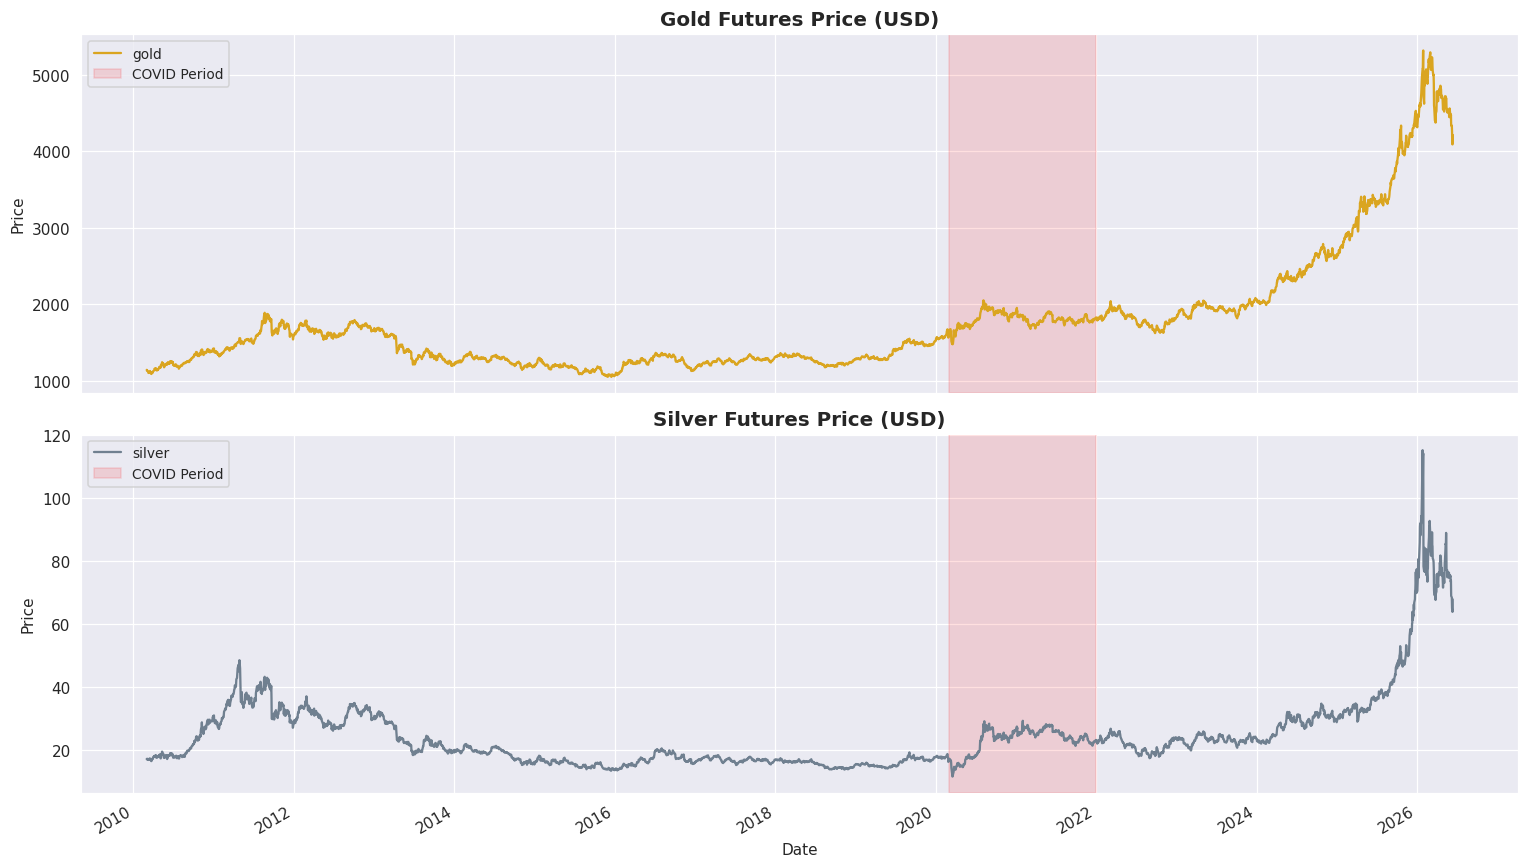

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

df['gold'].plot(ax=axes[0], color='goldenrod', linewidth=1.5)
axes[0].set_title('Gold Futures Price (USD)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price')

df['silver'].plot(ax=axes[1], color='slategray', linewidth=1.5)
axes[1].set_title('Silver Futures Price (USD)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price')

# Shade COVID period on both
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
               alpha=0.12, color='red', label='COVID Period')
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Log Returns — Time Series & Distribution

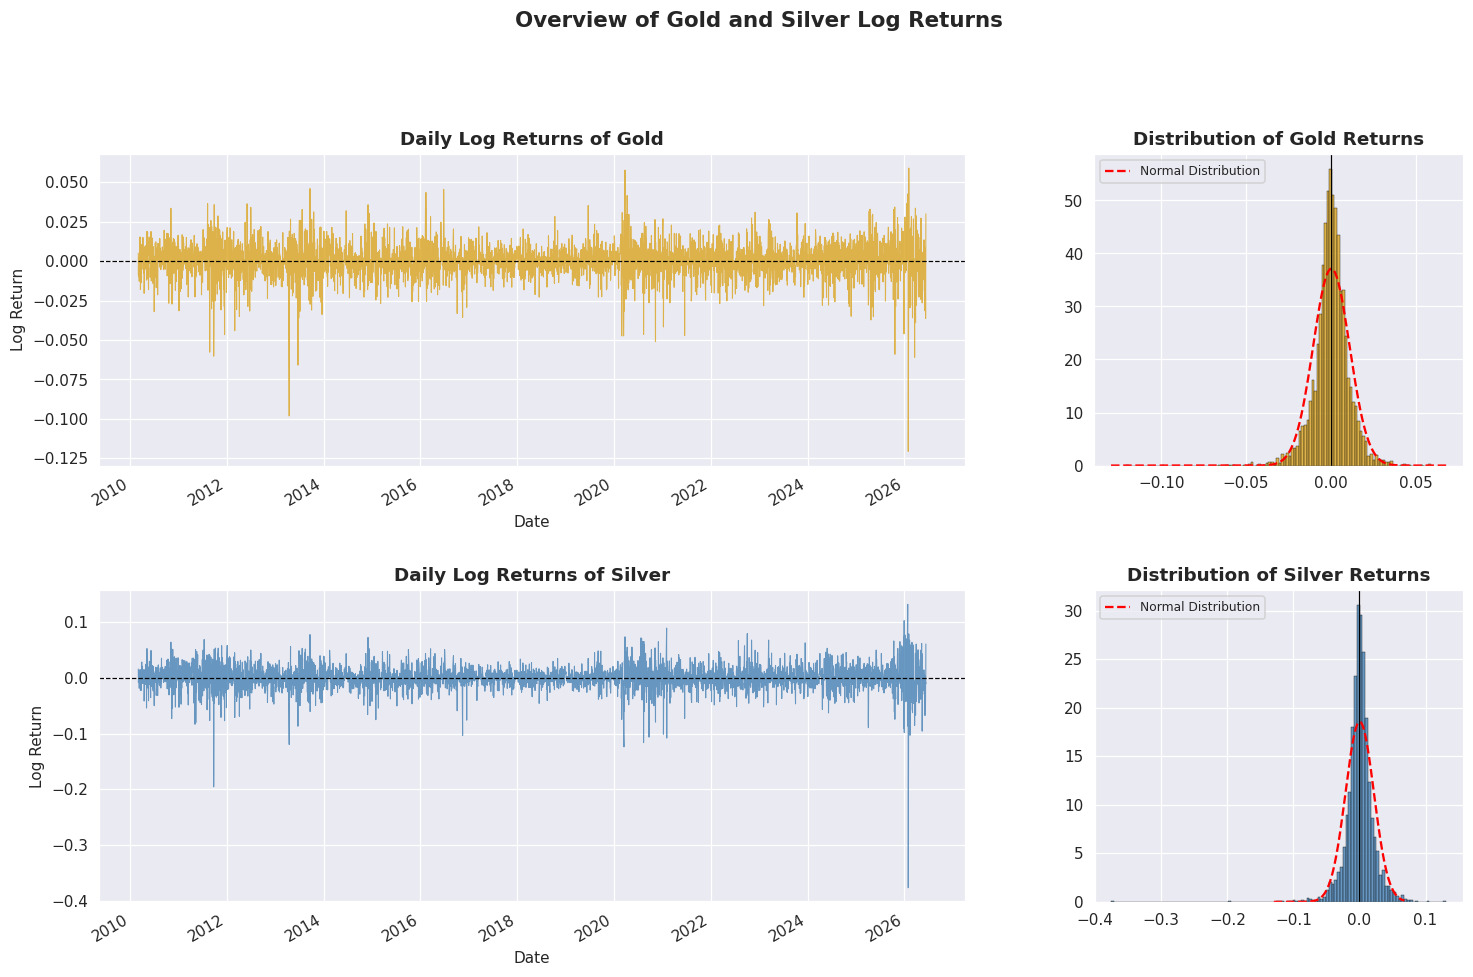

In [40]:
fig = plt.figure(figsize=(16, 10))
grid = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Time-series plot for gold log returns
gold_ax = fig.add_subplot(grid[0, :2])
df['au_returns'].plot(
    ax=gold_ax,
    color='goldenrod',
    linewidth=0.7,
    alpha=0.8
)
gold_ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
gold_ax.set_title('Daily Log Returns of Gold', fontweight='bold')
gold_ax.set_ylabel('Log Return')

# Histogram for gold returns
gold_hist_ax = fig.add_subplot(grid[0, 2])
gold_hist_ax.hist(
    df['au_returns'].dropna(),
    bins=120,
    color='goldenrod',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.8,
    density=True
)

x_min, x_max = gold_hist_ax.get_xlim()
x_vals = np.linspace(x_min, x_max, 200)

gold_mean = df['au_returns'].mean()
gold_std  = df['au_returns'].std()

gold_hist_ax.plot(
    x_vals,
    stats.norm.pdf(x_vals, gold_mean, gold_std),
    'r--',
    linewidth=1.5,
    label='Normal Distribution'
)

gold_hist_ax.axvline(0, color='black', linewidth=0.8)
gold_hist_ax.set_title('Distribution of Gold Returns', fontweight='bold')
gold_hist_ax.legend(fontsize=8)

# Time-series plot for silver log returns
silver_ax = fig.add_subplot(grid[1, :2])
df['ag_returns'].plot(
    ax=silver_ax,
    color='steelblue',
    linewidth=0.7,
    alpha=0.8
)

silver_ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
silver_ax.set_title('Daily Log Returns of Silver', fontweight='bold')
silver_ax.set_ylabel('Log Return')

# Histogram for silver returns
silver_hist_ax = fig.add_subplot(grid[1, 2])
silver_hist_ax.hist(
    df['ag_returns'].dropna(),
    bins=120,
    color='steelblue',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.8,
    density=True
)

silver_mean = df['ag_returns'].mean()
silver_std  = df['ag_returns'].std()

silver_hist_ax.plot(
    x_vals,
    stats.norm.pdf(x_vals, silver_mean, silver_std),
    'r--',
    linewidth=1.5,
    label='Normal Distribution'
)

silver_hist_ax.axvline(0, color='black', linewidth=0.8)
silver_hist_ax.set_title('Distribution of Silver Returns', fontweight='bold')
silver_hist_ax.legend(fontsize=8)

plt.suptitle(
    'Overview of Gold and Silver Log Returns',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.show()

## 3. Descriptive Statistics

In [41]:
desc = df[['au_returns', 'ag_returns']].describe().T
desc['skewness'] = df[['au_returns', 'ag_returns']].skew()
desc['kurtosis'] = df[['au_returns', 'ag_returns']].kurtosis()
desc['pct_positive'] = (df[['au_returns', 'ag_returns']] > 0).mean()

desc.index = ['Gold Returns', 'Silver Returns']
print("=== Descriptive Statistics ===")
print(desc.round(6).to_string())

print("\n=== Interpretation ===")
print(f"Gold  | Kurtosis={desc.loc['Gold Returns','kurtosis']:.2f}  → fat tails (leptokurtic)")
print(f"Silver| Kurtosis={desc.loc['Silver Returns','kurtosis']:.2f} → fatter tails")
print(f"Gold  | % Positive days = {desc.loc['Gold Returns','pct_positive']:.1%}")
print(f"Silver| % Positive days = {desc.loc['Silver Returns','pct_positive']:.1%}")

=== Descriptive Statistics ===
                 count      mean       std       min       25%       50%       75%       max  skewness   kurtosis  pct_positive
Gold Returns    4092.0  0.000320  0.010741 -0.120657 -0.004612  0.000450  0.005954  0.059054 -0.843170   8.786526      0.527859
Silver Returns  4092.0  0.000338  0.021502 -0.376103 -0.008872  0.000606  0.010010  0.131250 -1.830761  27.854327      0.518817

=== Interpretation ===
Gold  | Kurtosis=8.79  → fat tails (leptokurtic)
Silver| Kurtosis=27.85 → fatter tails
Gold  | % Positive days = 52.8%
Silver| % Positive days = 51.9%


## 4. Stationarity Tests (ADF + KPSS)

In [42]:
def stationarity_report(series, name):
    s = series.dropna()
    adf_stat, adf_p, *_, adf_crit = adfuller(s)
    kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')

    verdict = "STATIONARY" if (adf_p < 0.05 and kpss_p > 0.05) else               " CONFLICTING" if (adf_p < 0.05 or kpss_p > 0.05) else               " NON-STATIONARY"

    print(f"\n{'─'*52}")
    print(f"  {name}")
    print(f"{'─'*52}")
    print(f"  ADF  | stat={adf_stat:8.4f} | p={adf_p:.4f} | {'Stationary' if adf_p<0.05 else 'Non-Stationary'}")
    print(f"  KPSS | stat={kpss_stat:8.4f} | p={kpss_p:.4f} | {'Stationary' if kpss_p>0.05 else 'Non-Stationary'}")
    print(f"  → {verdict}")

print("=== PRICES (Raw) ===")
stationarity_report(df['gold'], 'Gold Price')
stationarity_report(df['silver'], 'Silver Price')

print("\n=== LOG RETURNS ===")
stationarity_report(df['au_returns'], 'Gold Log Returns')
stationarity_report(df['ag_returns'], 'Silver Log Returns')

=== PRICES (Raw) ===

────────────────────────────────────────────────────
  Gold Price
────────────────────────────────────────────────────
  ADF  | stat=  0.9107 | p=0.9932 | Non-Stationary
  KPSS | stat=  5.1357 | p=0.0100 | Non-Stationary
  →  NON-STATIONARY

────────────────────────────────────────────────────
  Silver Price
────────────────────────────────────────────────────
  ADF  | stat= -0.6015 | p=0.8706 | Non-Stationary
  KPSS | stat=  1.9647 | p=0.0100 | Non-Stationary
  →  NON-STATIONARY

=== LOG RETURNS ===

────────────────────────────────────────────────────
  Gold Log Returns
────────────────────────────────────────────────────
  ADF  | stat=-66.1340 | p=0.0000 | Stationary
  KPSS | stat=  0.3798 | p=0.0859 | Stationary
  → STATIONARY

────────────────────────────────────────────────────
  Silver Log Returns
────────────────────────────────────────────────────
  ADF  | stat=-11.3460 | p=0.0000 | Stationary
  KPSS | stat=  0.2228 | p=0.1000 | Stationary
  → STATIONARY


## 5. ACF / PACF — Returns & Squared Returns (Volatility Clustering Check)

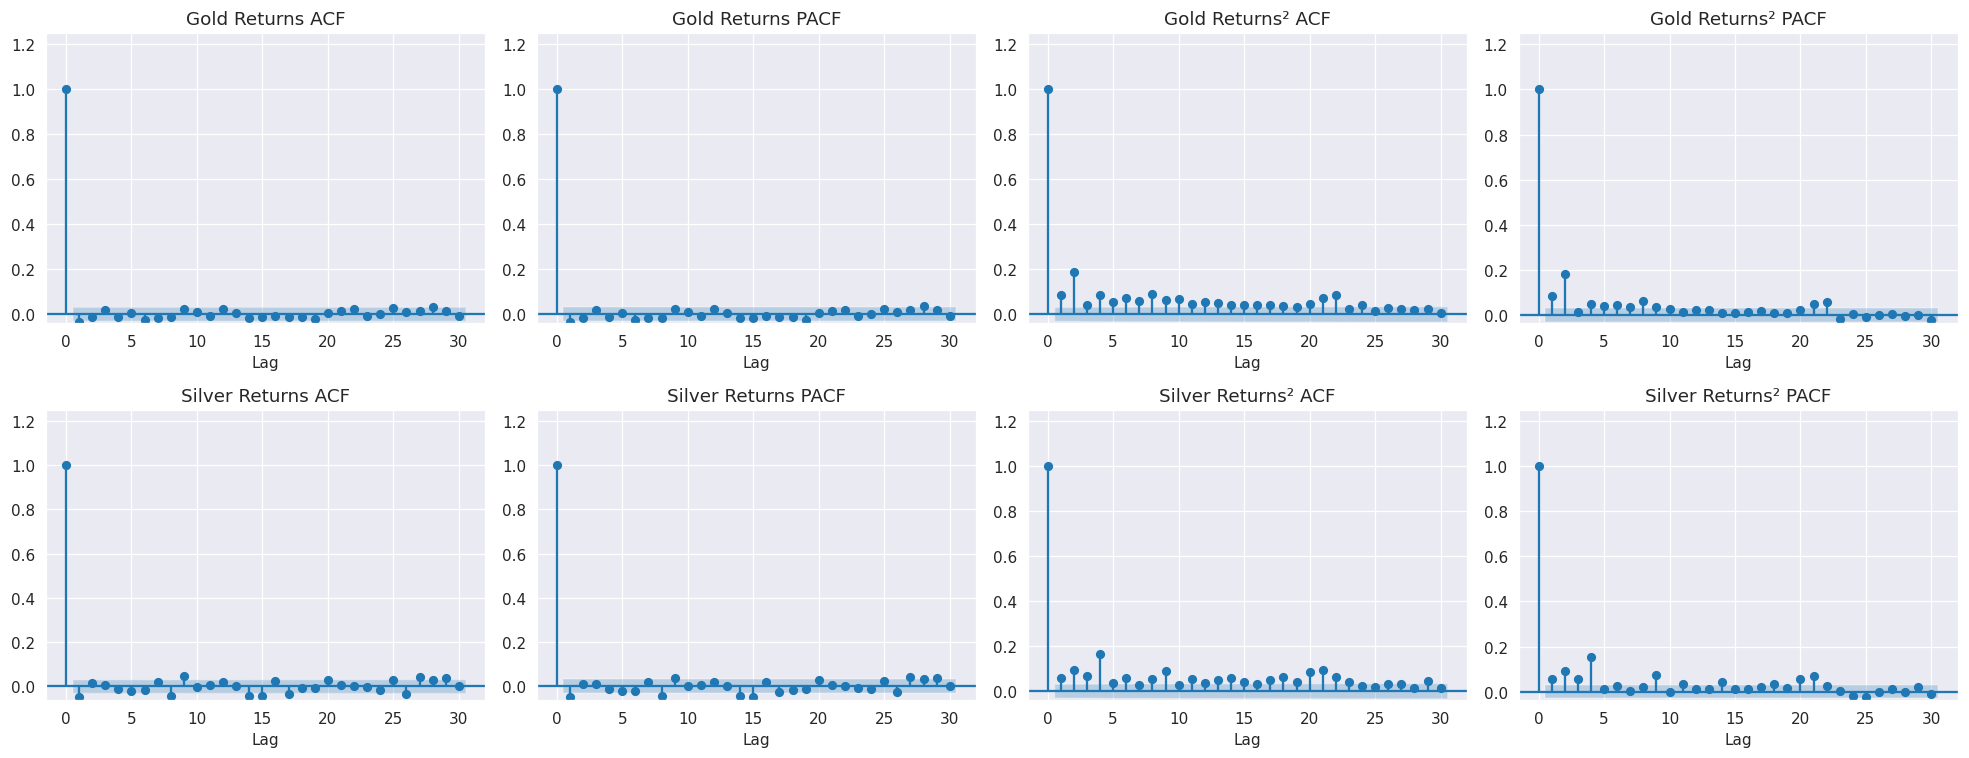

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
titles = ['Gold Returns ACF', 'Gold Returns PACF',
          'Gold Returns² ACF', 'Gold Returns² PACF',
          'Silver Returns ACF', 'Silver Returns PACF',
          'Silver Returns² ACF', 'Silver Returns² PACF']

au_ret = df['au_returns'].dropna()
ag_ret = df['ag_returns'].dropna()
series = [au_ret, au_ret, au_ret**2, au_ret**2,
          ag_ret, ag_ret, ag_ret**2, ag_ret**2]
funcs  = [plot_acf, plot_pacf, plot_acf, plot_pacf] * 2

for ax, fn, s, t in zip(axes.flatten(), funcs, series, titles):
    fn(s, lags=30, ax=ax, title=t, auto_ylims=True)
    ax.set_xlabel('Lag')

plt.tight_layout()
plt.show()

## 6. Macro Features — VIX, Interest, USD Index

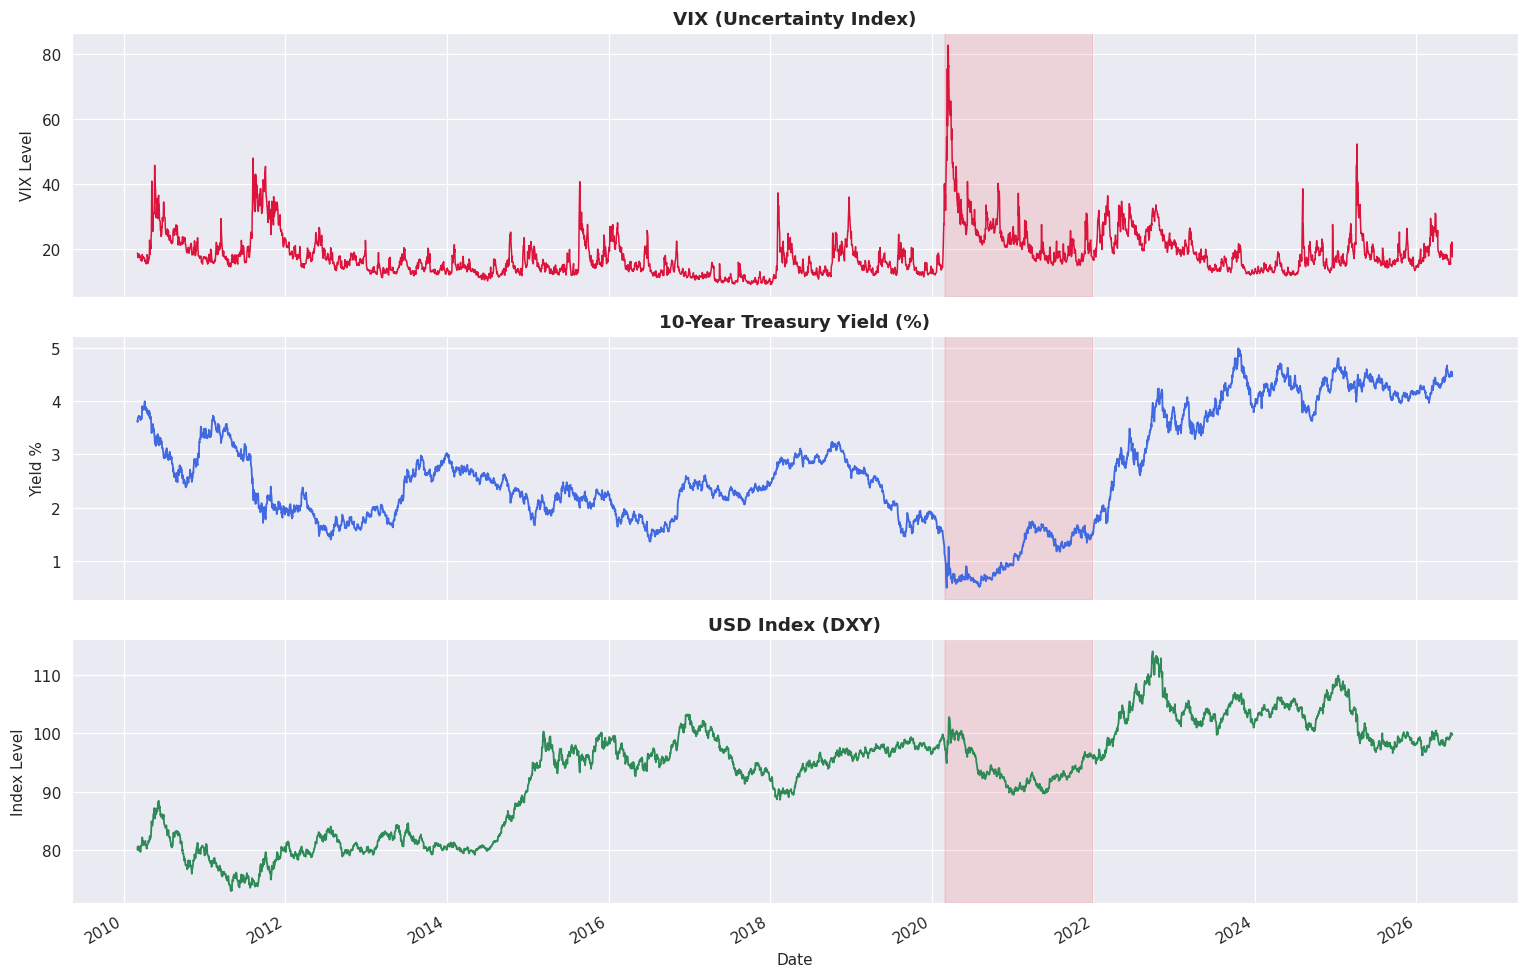

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

df['vix'].plot(ax=axes[0], color='crimson', linewidth=1, label='VIX')
axes[0].set_title('VIX (Uncertainty Index)', fontweight='bold')
axes[0].set_ylabel('VIX Level')

df['interest'].plot(ax=axes[1], color='royalblue', linewidth=1.2)
axes[1].set_title('10-Year Treasury Yield (%)', fontweight='bold')
axes[1].set_ylabel('Yield %')

df['usd_idx'].plot(ax=axes[2], color='seagreen', linewidth=1.2)
axes[2].set_title('USD Index (DXY)', fontweight='bold')
axes[2].set_ylabel('Index Level')

for ax in axes:
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
               alpha=0.1, color='red', label='COVID')

plt.tight_layout()
plt.show()

## 7. Correlation Matrix

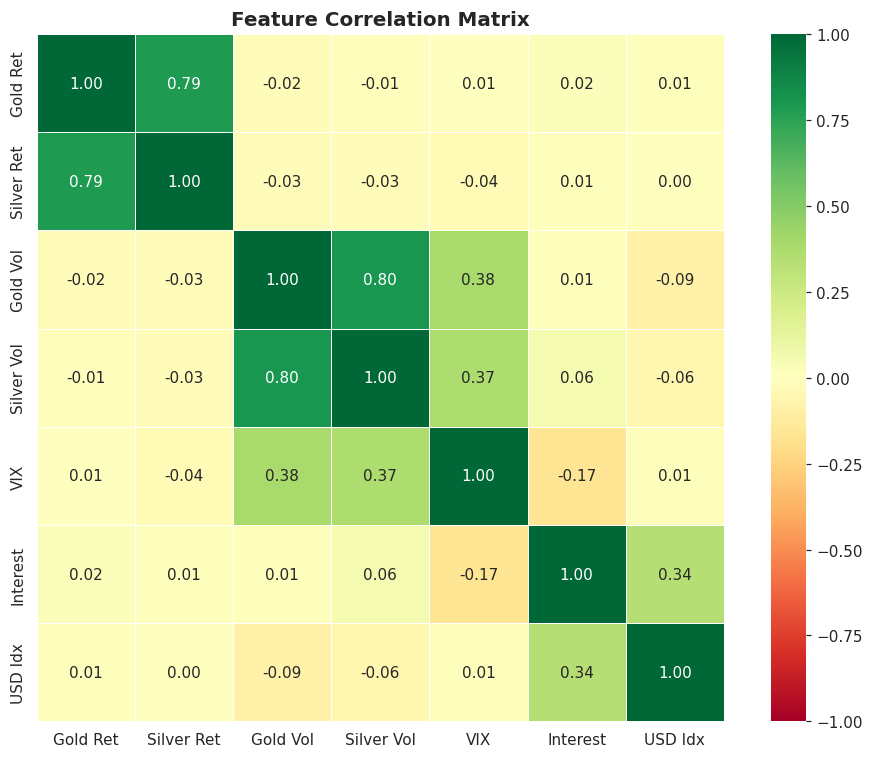

In [45]:
cols = ['au_returns', 'ag_returns', 'au_vol', 'ag_vol',
        'vix', 'interest', 'usd_idx']
labels = ['Gold Ret', 'Silver Ret', 'Gold Vol', 'Silver Vol',
          'VIX', 'Interest', 'USD Idx']

corr = df[cols].corr()
corr.index = labels
corr.columns = labels

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            mask=False, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Rolling Correlation — Gold vs Silver

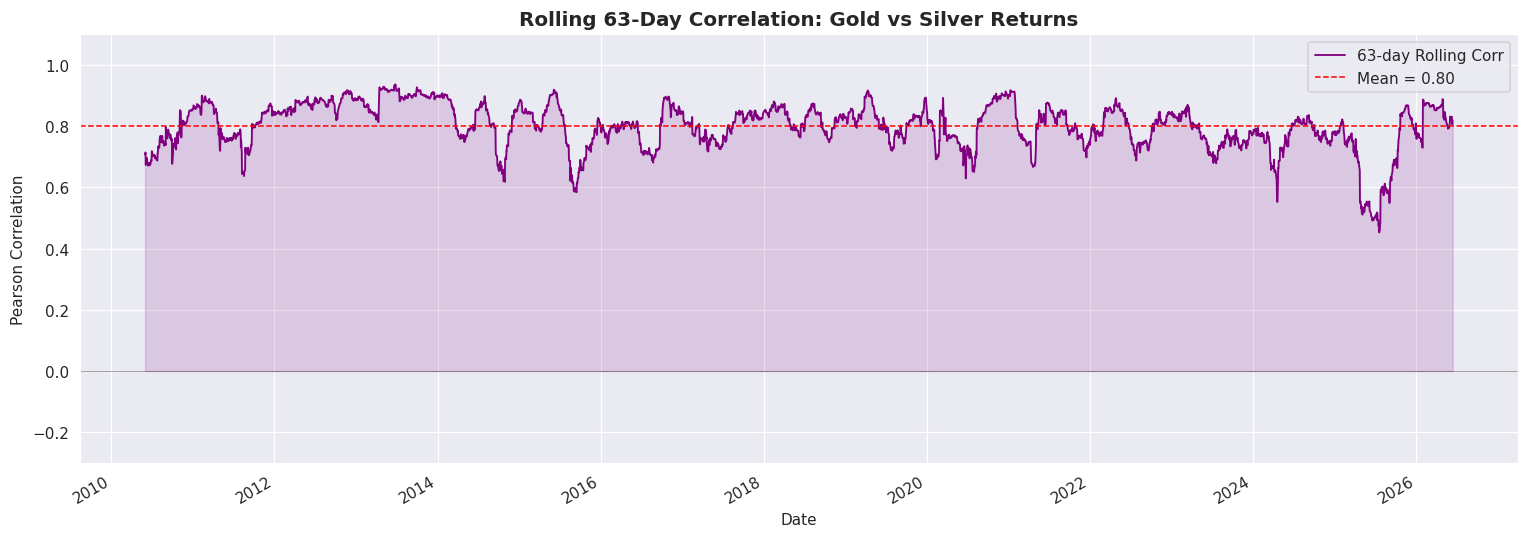

Mean correlation: 0.800
Min:  0.453  |  Max: 0.936


In [46]:
roll_corr = df['au_returns'].rolling(63).corr(df['ag_returns'])  # ~3 months

plt.figure(figsize=(14, 5))
roll_corr.plot(color='purple', linewidth=1.2, label='63-day Rolling Corr')
plt.axhline(roll_corr.mean(), color='red', linestyle='--', linewidth=1,
            label=f'Mean = {roll_corr.mean():.2f}')
plt.axhline(0, color='black', linewidth=0.6, alpha=0.4)
plt.fill_between(roll_corr.index, roll_corr, alpha=0.15, color='purple')
plt.title('Rolling 63-Day Correlation: Gold vs Silver Returns', fontsize=13, fontweight='bold')
plt.ylabel('Pearson Correlation')
plt.ylim(-0.3, 1.1)
plt.legend()
plt.tight_layout()
plt.show()
print(f"Mean correlation: {roll_corr.mean():.3f}")
print(f"Min:  {roll_corr.min():.3f}  |  Max: {roll_corr.max():.3f}")

## 9. Year-wise Summary Statistics

      Gold_MeanRet  Silver_MeanRet  Gold_Vol  Silver_Vol  Gold_PctUp  Silver_PctUp
year                                                                              
2010       0.00106         0.00282   0.00935     0.01934     0.61611       0.60664
2011       0.00038        -0.00041   0.01334     0.03048     0.56746       0.56349
2012       0.00027         0.00032   0.01028     0.01931     0.52000       0.47600
2013      -0.00132        -0.00177   0.01417     0.02126     0.45635       0.46429
2014      -0.00006        -0.00086   0.00894     0.01535     0.47222       0.48810
2015      -0.00044        -0.00048   0.00928     0.01692     0.44444       0.48016
2016       0.00032         0.00058   0.01023     0.01715     0.48800       0.53200
2017       0.00051         0.00027   0.00654     0.01106     0.54980       0.50598
2018      -0.00009        -0.00040   0.00664     0.01138     0.48000       0.47200
2019       0.00069         0.00057   0.00725     0.01238     0.54365       0.53571
2020

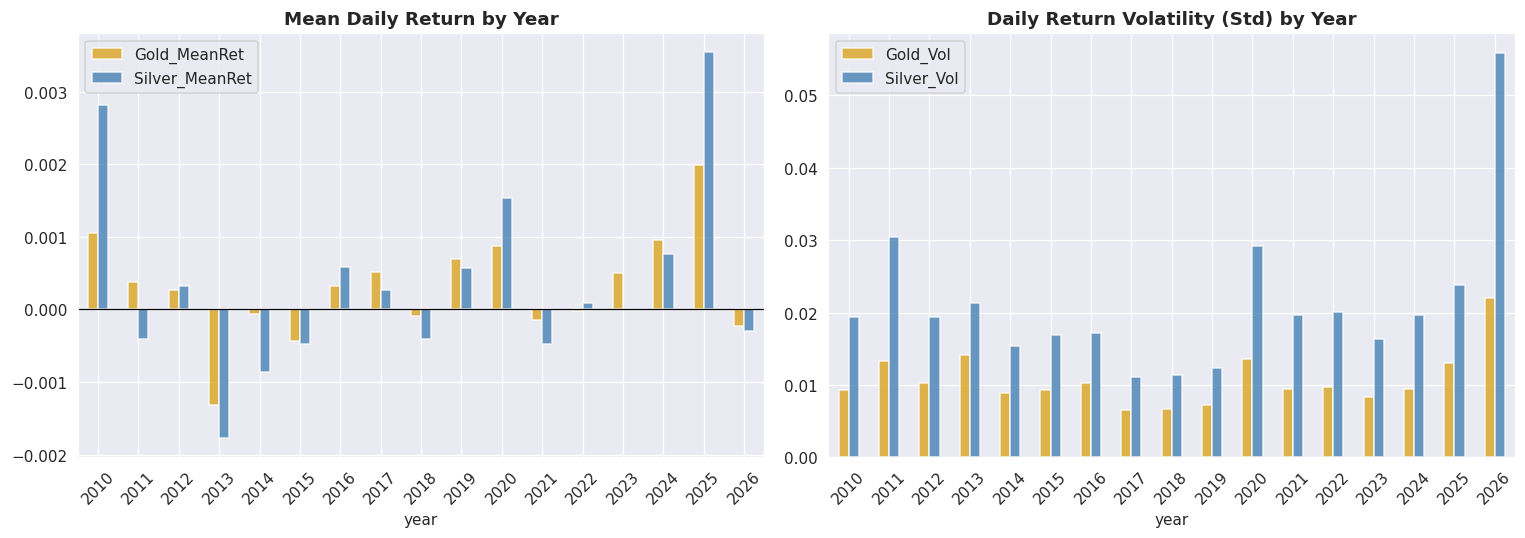

In [47]:
df['year'] = df.index.year
yw = df.groupby('year').agg(
    Gold_MeanRet  = ('au_returns', 'mean'),
    Silver_MeanRet= ('ag_returns', 'mean'),
    Gold_Vol      = ('au_returns', 'std'),
    Silver_Vol    = ('ag_returns', 'std'),
    Gold_PctUp    = ('au_returns', lambda x: (x > 0).mean()),
    Silver_PctUp  = ('ag_returns', lambda x: (x > 0).mean()),
).round(5)

print(yw.to_string())

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yw[['Gold_MeanRet','Silver_MeanRet']].plot(kind='bar', ax=axes[0],
    color=['goldenrod','steelblue'], alpha=0.8)
axes[0].set_title('Mean Daily Return by Year', fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticklabels(yw.index, rotation=45)

yw[['Gold_Vol','Silver_Vol']].plot(kind='bar', ax=axes[1],
    color=['goldenrod','steelblue'], alpha=0.8)
axes[1].set_title('Daily Return Volatility (Std) by Year', fontweight='bold')
axes[1].set_xticklabels(yw.index, rotation=45)

plt.tight_layout()
plt.show()
df.drop(columns=['year'], inplace=True)